Data path: /content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR/

HAR Reconcile v3 — Fixed: Conflict-Aware Reconciliation
Device: cuda

Loading UCI-HAR from: /content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR/
  Train: (7352, 128, 9), Test: (2947, 128, 9)
  After preprocessing: train=(7352, 9, 128), test=(2947, 9, 128)
  Model parameters: 619,107

Ep   1/100 | lr=6.0e-05 | Tr acc=0.6721 F1=0.6210 | Va acc=0.7313 F1=0.6945 | λ=0.547±0.000 | 7.8s
Ep   5/100 | lr=3.0e-04 | Tr acc=0.9356 F1=0.9387 | Va acc=0.8914 F1=0.8912 | λ=0.578±0.009 | 3.8s
Ep  10/100 | lr=3.0e-04 | Tr acc=0.9509 F1=0.9543 | Va acc=0.9213 F1=0.9218 | λ=0.567±0.062 | 4.5s
Ep  15/100 | lr=2.9e-04 | Tr acc=0.9571 F1=0.9602 | Va acc=0.9199 F1=0.9196 | λ=0.561±0.071 | 3.9s
Ep  20/100 | lr=2.8e-04 | Tr acc=0.9663 F1=0.9688 | Va acc=0.9233 F1=0.9230 | λ=0.561±0.077 | 3.7s
Ep  25/100 | lr=2.7e-04 | Tr acc=0.9701 F1=0.9724 | Va acc=0.9287 F1=0.9295 | λ=0.571±0.080 | 7.0s
Ep  30/100 | lr=2.6e-04 | Tr acc=0.9751 F1=0.9770 

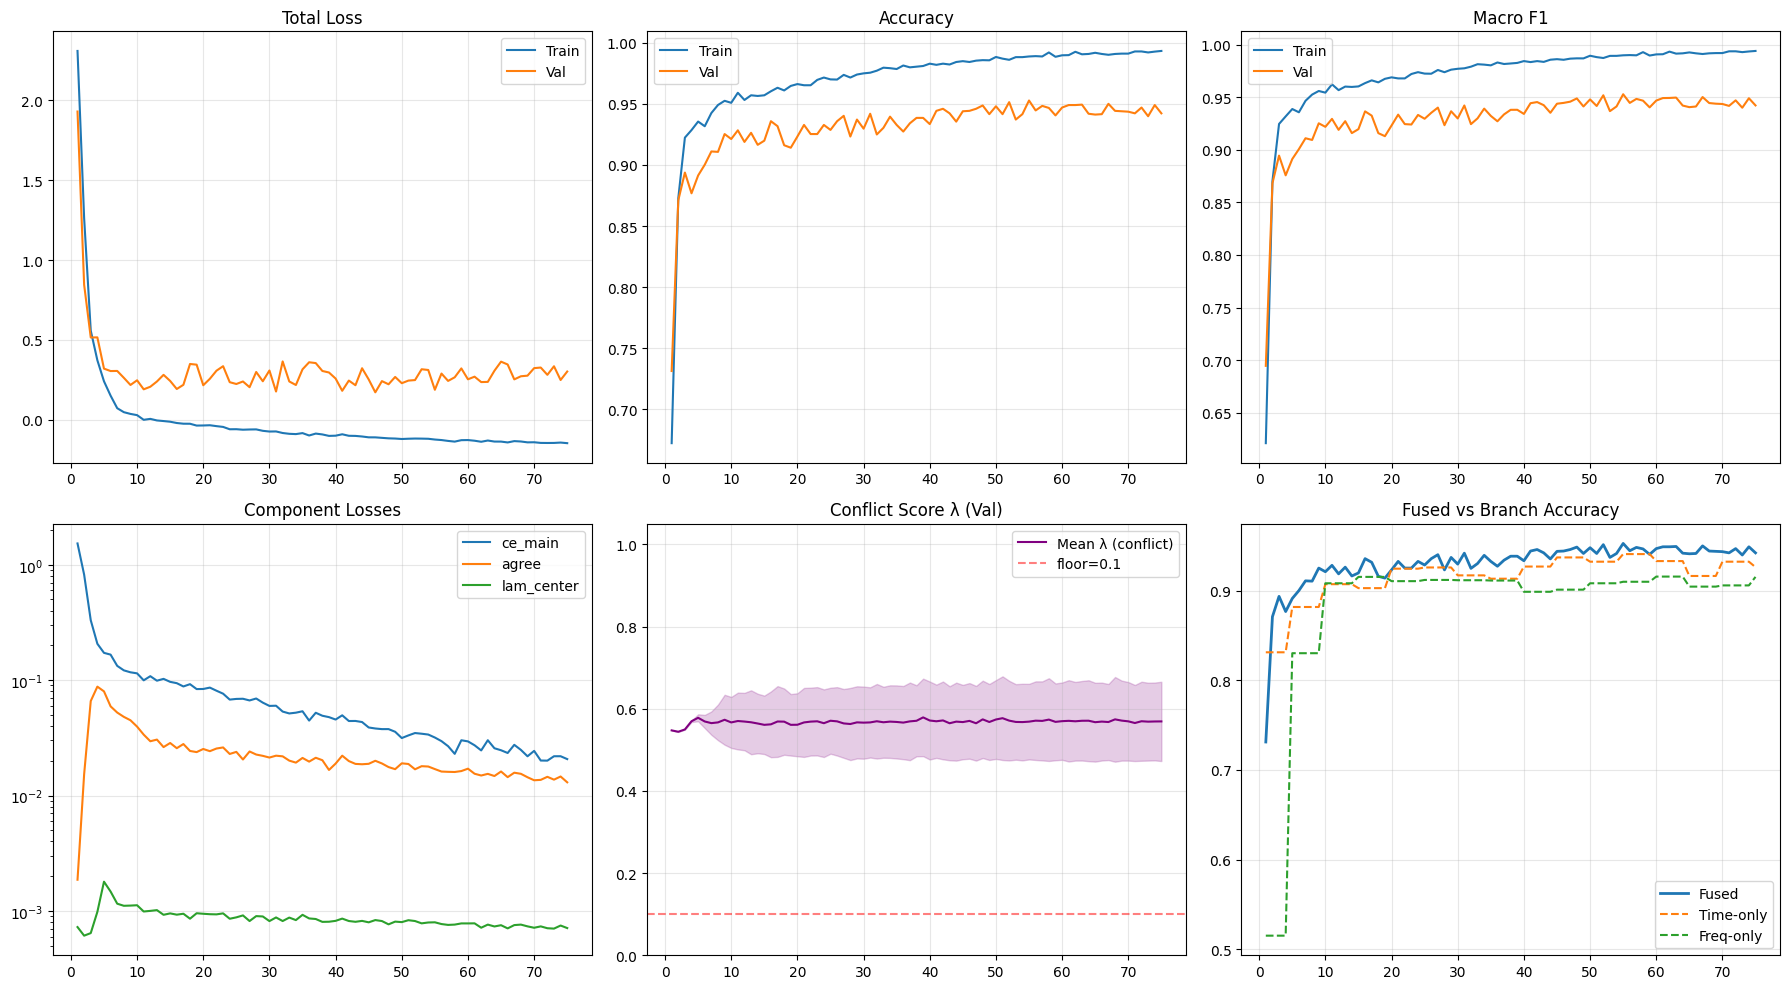

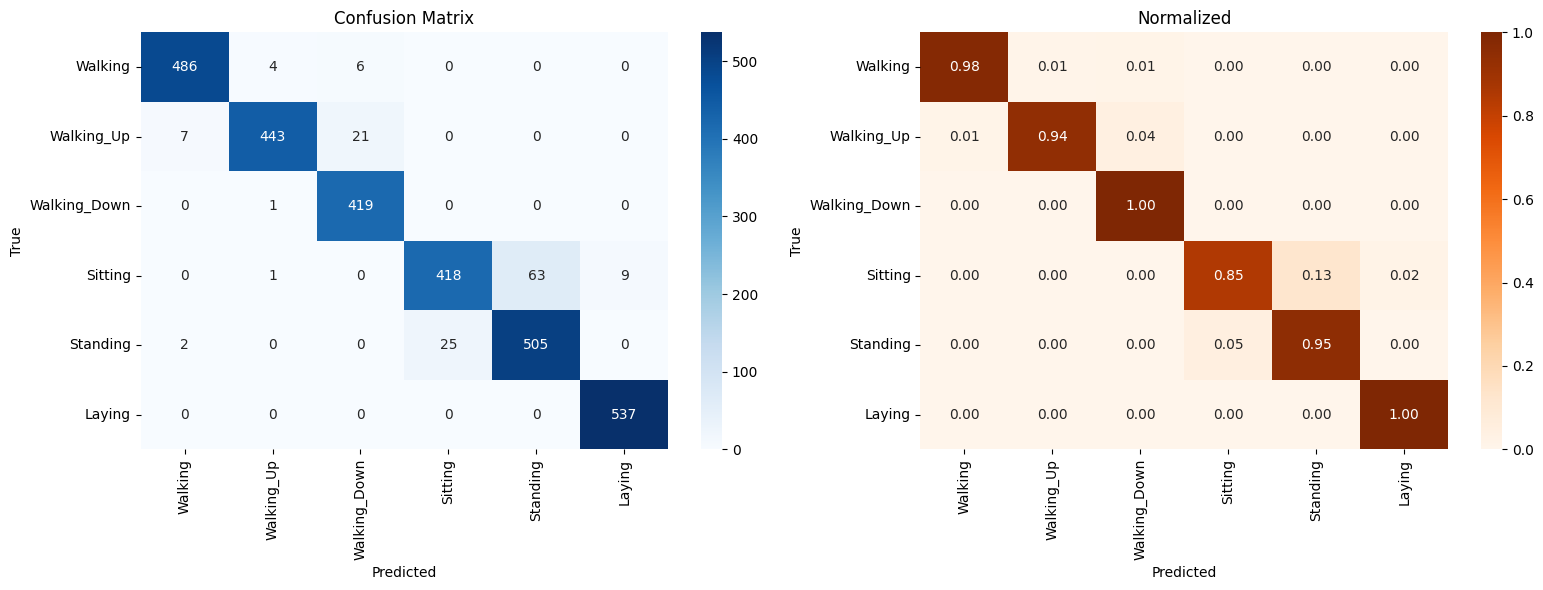

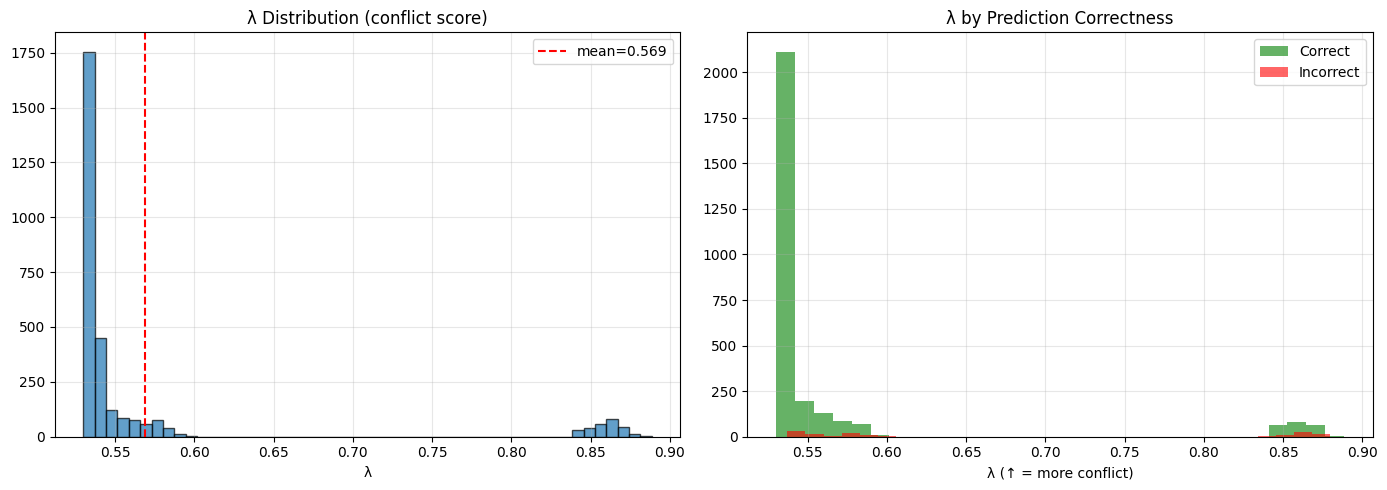

  Model saved to results/har_reconcile_v3_best.pt


In [2]:
"""
=============================================================================
HAR Reconcile Pipeline v3 — Fixed + Saturation Patch
변경 요약:
  1. λ = conflict score로 명확히 정의
     → agreement loss: (1 - lam) * l_agree_raw  (low conflict → 강한 agreement)
  2. ConflictAwareFusion: lam을 직접 fusion gate에 반영
     high conflict → 보수적 평균 블렌드 / low conflict → 강한 cross-domain interaction
  3. ConflictEstimator [SAT-FIX]:
     - LayerNorm 제거 → 의미 기반 per-feature [0,1] 정규화
       cos_sim→(+1)/2, l2→normalize+clamp, ent→/log(K), top1_agree→0/1
     - MLP 입력이 [0,1]로 안정화 → sigmoid 포화 완화
  4. ReconcileLoss [SAT-FIX]:
     - lambda_center_reg: mean(λ)→0.5 직접 유도 (upper saturation 방지)
     - lambda_ent_weight: 0.1→0.3 (spread 유도 강화)
  5. 최종 classifier에 branch residual 경로 추가
=============================================================================
"""

import os
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


# ============================================================================
# Config
# ============================================================================
class Config:
    data_dir = "/content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR/"
    n_channels = 9
    seq_len = 128
    n_classes = 6

    stft_bins_per_scale = 16
    stft_kernel_sizes = [32, 64]
    stft_hop = 8
    freq_cnn_dim = 128

    latent_n = 32
    latent_d = 128
    perceiver_heads = 4
    perceiver_blocks = 2
    perceiver_dim = 128
    dropout = 0.1

    batch_size = 64
    epochs = 100
    lr = 3e-4
    weight_decay = 1e-4
    warmup_epochs = 5

    alpha_agree = 0.5
    lambda_floor = 0.1
    lambda_ent_weight = 0.3          # [SAT-FIX] 0.1 → 0.3: spread 유도 강화
    lambda_center_weight = 0.3       # [SAT-FIX] 신규: mean(λ)→0.5 center 유도
    lambda_center_target = 0.5       # 목표 중심값 (필요 시 조정)
    # residual branch mixing weight
    residual_branch_weight = 0.15

    seed = 42
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    activity_labels = [
        'Walking', 'Walking_Up', 'Walking_Down',
        'Sitting', 'Standing', 'Laying'
    ]


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================================
# Data Loading
# ============================================================================
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]


def load_uci_har_split(data_dir, split='train'):
    inertial_dir = os.path.join(data_dir, split, "Inertial Signals")
    signals = []
    for sig in SIGNALS:
        fpath = os.path.join(inertial_dir, f"{sig}_{split}.txt")
        data = np.loadtxt(fpath, dtype=np.float32)
        signals.append(data)
    X = np.stack(signals, axis=-1)  # (N, 128, 9)
    y = np.loadtxt(os.path.join(data_dir, split, f"y_{split}.txt"), dtype=np.int32) - 1
    return X, y


def load_uci_har(cfg):
    print(f"Loading UCI-HAR from: {cfg.data_dir}")
    X_train_raw, y_train = load_uci_har_split(cfg.data_dir, 'train')
    X_test_raw, y_test  = load_uci_har_split(cfg.data_dir, 'test')
    print(f"  Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")

    N_tr, T, C = X_train_raw.shape
    N_te = X_test_raw.shape[0]

    scaler = StandardScaler()
    scaler.fit(X_train_raw.reshape(-1, C))
    X_train = scaler.transform(X_train_raw.reshape(-1, C)).reshape(N_tr, T, C)
    X_test  = scaler.transform(X_test_raw.reshape(-1, C)).reshape(N_te, T, C)

    X_train = X_train.transpose(0, 2, 1)
    X_test  = X_test.transpose(0, 2, 1)
    print(f"  After preprocessing: train={X_train.shape}, test={X_test.shape}")
    return X_train, y_train, X_test, y_test


class HARDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if torch.rand(1).item() < 0.5:
                x = x * (1.0 + 0.1 * torch.randn(x.size(0), 1))
            if torch.rand(1).item() < 0.5:
                x = x + 0.02 * torch.randn_like(x)
            if torch.rand(1).item() < 0.3:
                ch = torch.randint(0, x.size(0), (1,)).item()
                x[ch] = 0.0
        return x, self.y[idx]


# ============================================================================
# Model Components
# ============================================================================
class MultiScaleLearnableSTFT(nn.Module):
    def __init__(self, in_ch, bins_per_scale=16, kernel_sizes=[32, 64], hop=8):
        super().__init__()
        self.banks = nn.ModuleList()
        self.norms = nn.ModuleList()
        for ks in kernel_sizes:
            self.banks.append(
                nn.Conv1d(in_ch, bins_per_scale, kernel_size=ks,
                          stride=hop, padding=ks // 2, bias=False)
            )
            self.norms.append(nn.BatchNorm1d(bins_per_scale))

    def forward(self, x):
        specs = []
        for conv, bn in zip(self.banks, self.norms):
            c    = conv(x)
            mag  = torch.sqrt(c ** 2 + 1e-6)
            logm = bn(torch.log1p(mag))
            specs.append(logm)
        min_t = min(s.size(2) for s in specs)
        specs = [s[:, :, :min_t] for s in specs]
        return torch.cat(specs, dim=1).unsqueeze(1)


class FreqEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 24, 3, padding=1), nn.BatchNorm2d(24), nn.GELU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(24, 48, 3, padding=1), nn.BatchNorm2d(48), nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Sequential(
            nn.Linear(48, out_dim), nn.LayerNorm(out_dim), nn.GELU()
        )

    def forward(self, x):
        h = self.net(x).view(x.size(0), -1)
        return self.fc(h)


class PerceiverCrossAttention(nn.Module):
    def __init__(self, d_latent, d_input, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn   = nn.MultiheadAttention(d_latent, n_heads, batch_first=True, dropout=dropout)
        self.norm_q = nn.LayerNorm(d_latent)
        self.norm_kv = nn.LayerNorm(d_input)
        self.proj_kv = nn.Linear(d_input, d_latent) if d_input != d_latent else nn.Identity()

    def forward(self, latents, inputs):
        q  = self.norm_q(latents)
        kv = self.proj_kv(self.norm_kv(inputs))
        out, _ = self.attn(q, kv, kv)
        return latents + out


class PerceiverSelfBlock(nn.Module):
    def __init__(self, d_latent, n_heads=4, ff_mult=2, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_latent)
        self.attn  = nn.MultiheadAttention(d_latent, n_heads, batch_first=True, dropout=dropout)
        self.norm2 = nn.LayerNorm(d_latent)
        self.ffn   = nn.Sequential(
            nn.Linear(d_latent, d_latent * ff_mult), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_latent * ff_mult, d_latent), nn.Dropout(dropout),
        )

    def forward(self, x):
        h = self.norm1(x)
        x = x + self.attn(h, h, h)[0]
        x = x + self.ffn(self.norm2(x))
        return x


class PerceiverTimeEncoder(nn.Module):
    def __init__(self, in_dim, latent_n=32, latent_d=128, n_heads=4,
                 num_blocks=2, out_dim=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, latent_d), nn.LayerNorm(latent_d)
        )
        self.pos_enc   = nn.Parameter(torch.randn(1, 512, latent_d) * 0.02)
        self.latents   = nn.Parameter(torch.randn(1, latent_n, latent_d) * 0.02)
        self.cross_attn = PerceiverCrossAttention(latent_d, latent_d, n_heads, dropout)
        self.self_blocks = nn.ModuleList([
            PerceiverSelfBlock(latent_d, n_heads, ff_mult=2, dropout=dropout)
            for _ in range(num_blocks)
        ])
        self.norm_out = nn.LayerNorm(latent_d)
        self.fc_out   = nn.Sequential(
            nn.Linear(latent_d, out_dim), nn.LayerNorm(out_dim), nn.GELU()
        )

    def forward(self, x):
        B, T, _ = x.shape
        inp     = self.input_proj(x) + self.pos_enc[:, :T, :]
        latents = self.latents.expand(B, -1, -1)
        latents = self.cross_attn(latents, inp)
        for blk in self.self_blocks:
            latents = blk(latents)
        return self.fc_out(self.norm_out(latents).mean(dim=1))


# ============================================================================
# [SAT-FIX] ConflictEstimator — semantic per-feature [0,1] normalization
#   LayerNorm 제거:
#     LayerNorm은 sample 내 feature 간 상대값만 맞춤 → 절댓값 극단 허용
#   대신 각 feature를 의미적으로 [0,1]로 스케일:
#     cos_sim  : [-1, 1] → [0, 1]
#     l2_norm  : [0, ∞) → clamp [0, 1]
#     ent_t/f  : [0, log(K)] → [0, 1]
#     top1_agree: already 0/1
# ============================================================================
class ConflictEstimator(nn.Module):
    """
    λ = conflict score ∈ [lambda_floor, 1]
    high λ → 두 branch가 불일치 (high conflict)
    low  λ → 두 branch가 일치   (low conflict)

    stop-gradient on all inputs → conflict estimator는
    classification gradient를 통해 직접 훈련되지 않음
    (lambda_floor + entropy_reg + center_reg으로 collapse/saturation 방지)
    """
    def __init__(self, n_features=5, lambda_floor=0.1, n_classes=6):
        super().__init__()
        self.lambda_floor = lambda_floor
        self.log_k = math.log(n_classes)   # entropy 정규화 상수
        self.mlp = nn.Sequential(
            nn.Linear(n_features, 32), nn.GELU(),
            nn.Linear(32, 1),
        )

    def forward(self, z_t, z_f, p_t, p_f):
        z_t_d = z_t.detach()
        z_f_d = z_f.detach()
        p_t_d = p_t.detach()
        p_f_d = p_f.detach()

        # ── feature 1: cosine similarity → [0,1]  (1=완전 유사, 0=완전 반대)
        cos_sim  = F.cosine_similarity(z_t_d, z_f_d, dim=-1, eps=1e-6)
        cos_norm = (cos_sim + 1.0) / 2.0                         # [-1,1] → [0,1]

        # ── feature 2: normalized L2 distance → [0,1] clamp
        l2_dist   = torch.norm(z_t_d - z_f_d, dim=-1, p=2)
        denom     = z_t_d.norm(dim=-1) + z_f_d.norm(dim=-1) + 1e-6
        l2_norm   = (l2_dist / denom).clamp(0.0, 1.0)            # scale-invariant + bounded

        # ── feature 3~4: entropy → [0,1]  (1=최대 불확실)
        ent_t = (-(p_t_d * (p_t_d + 1e-8).log()).sum(dim=-1) / self.log_k).clamp(0.0, 1.0)
        ent_f = (-(p_f_d * (p_f_d + 1e-8).log()).sum(dim=-1) / self.log_k).clamp(0.0, 1.0)

        # ── feature 5: top-1 agreement (1=일치, 0=불일치)
        top1_agree = (p_t_d.argmax(dim=-1) == p_f_d.argmax(dim=-1)).float()

        features = torch.stack([cos_norm, l2_norm, ent_t, ent_f, top1_agree], dim=-1)
        # LayerNorm 제거: 위에서 이미 의미적으로 [0,1] 보장됨
        # → MLP 입력 범위가 [0,1]로 안정적 → sigmoid 포화 완화

        raw = torch.sigmoid(self.mlp(features).squeeze(-1))
        lam = self.lambda_floor + (1.0 - self.lambda_floor) * raw
        return lam  # (B,), conflict score: high → disagreement


# ============================================================================
# [FIX 2] ConflictAwareFusion — CrossDomainReconciliation 대체
#   lam을 fusion gate에 직접 반영:
#     low  conflict → z_cross (강한 cross-domain interaction)
#     high conflict → z_mean  (보수적 평균 블렌드)
# ============================================================================
class ConflictAwareFusion(nn.Module):
    def __init__(self, feat_dim, dropout=0.1):
        super().__init__()
        # learnable cross-domain projections
        self.proj_t = nn.Linear(feat_dim, feat_dim)
        self.proj_f = nn.Linear(feat_dim, feat_dim)

        # gate: decides how much each branch contributes in the cross-domain blend
        self.gate = nn.Sequential(
            nn.Linear(feat_dim * 2 + 1, feat_dim),   # +1 for lam scalar
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, feat_dim),
            nn.Sigmoid()
        )

        self.out_proj = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.GELU()
        )

    def forward(self, z_t, z_f, lam):
        """
        z_t, z_f : (B, D)
        lam       : (B,)  conflict score

        Fusion rule:
          z_cross = gate * proj_t(z_t) + (1-gate) * proj_f(z_f)   ← cross-domain blend
          z_mean  = 0.5 * (z_t + z_f)                              ← conservative mean
          z_out   = (1-lam) * z_cross + lam * z_mean
            low conflict  → z_cross 비중 ↑  (강한 reconciliation)
            high conflict → z_mean 비중 ↑   (보수적 fusion)
        """
        lam_e = lam.unsqueeze(-1)                               # (B, 1)
        gate  = self.gate(torch.cat([z_t, z_f, lam_e], dim=-1))
        z_cross = gate * self.proj_t(z_t) + (1 - gate) * self.proj_f(z_f)
        z_mean  = 0.5 * (z_t + z_f)
        z_fused = (1.0 - lam_e) * z_cross + lam_e * z_mean
        return self.out_proj(z_fused)


class BranchClassifier(nn.Module):
    def __init__(self, feat_dim, n_classes):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(feat_dim, feat_dim), nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(feat_dim, n_classes),
        )

    def forward(self, x):
        return self.head(x)


# ============================================================================
# Full Model
# ============================================================================
class HARReconcileModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # Freq branch
        self.stft         = MultiScaleLearnableSTFT(
            in_ch=cfg.n_channels, bins_per_scale=cfg.stft_bins_per_scale,
            kernel_sizes=cfg.stft_kernel_sizes, hop=cfg.stft_hop,
        )
        self.freq_encoder = FreqEncoder(out_dim=cfg.freq_cnn_dim)

        # Time branch
        self.time_encoder = PerceiverTimeEncoder(
            in_dim=cfg.n_channels, latent_n=cfg.latent_n, latent_d=cfg.latent_d,
            n_heads=cfg.perceiver_heads, num_blocks=cfg.perceiver_blocks,
            out_dim=cfg.perceiver_dim, dropout=cfg.dropout,
        )

        assert cfg.freq_cnn_dim == cfg.perceiver_dim
        feat_dim = cfg.perceiver_dim

        # [FIX 2] Conflict-aware fusion (replaces CrossDomainReconciliation)
        self.fusion = ConflictAwareFusion(feat_dim=feat_dim, dropout=cfg.dropout)

        # Branch classifiers
        self.cls_time = BranchClassifier(feat_dim, cfg.n_classes)
        self.cls_freq = BranchClassifier(feat_dim, cfg.n_classes)

        # [FIX 4] Branch residual projection (before main classifier)
        self.residual_proj = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.LayerNorm(feat_dim),
        )

        # Main classifier
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, feat_dim), nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(feat_dim, cfg.n_classes),
        )

        # Conflict estimator
        self.conflict_est = ConflictEstimator(
            n_features=5, lambda_floor=cfg.lambda_floor, n_classes=cfg.n_classes,
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.Conv1d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        """
        x: (B, C, T)
        Returns:
            logits    : fused prediction
            logits_t  : time-branch prediction
            logits_f  : freq-branch prediction
            features  : auxiliary tensors
        """
        # ── Frequency branch ──────────────────────────────────────────────
        spec = self.stft(x)
        z_f  = self.freq_encoder(spec)

        # ── Time branch ───────────────────────────────────────────────────
        z_t  = self.time_encoder(x.permute(0, 2, 1))

        # ── Branch predictions ────────────────────────────────────────────
        logits_t = self.cls_time(z_t)
        logits_f = self.cls_freq(z_f)
        p_t = F.softmax(logits_t, dim=-1)
        p_f = F.softmax(logits_f, dim=-1)

        # ── Conflict score (detach inside estimator) ──────────────────────
        lam = self.conflict_est(z_t, z_f, p_t, p_f)   # (B,), high = conflict

        # ── [FIX 2] Conflict-aware fusion ─────────────────────────────────
        z_fused = self.fusion(z_t, z_f, lam)

        # ── [FIX 4] Branch residual + final classification ────────────────
        w = self.cfg.residual_branch_weight
        z_out = z_fused + w * self.residual_proj(z_t + z_f)
        logits = self.classifier(z_out)

        features = {
            'z_t': z_t, 'z_f': z_f, 'z_fused': z_fused,
            'lam': lam, 'p_t': p_t, 'p_f': p_f,
        }
        return logits, logits_t, logits_f, features


# ============================================================================
# Loss
# ============================================================================
class ReconcileLoss(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.ce  = nn.CrossEntropyLoss()

    def forward(self, logits, logits_t, logits_f, features, labels):
        losses = {}

        # 1. Classification losses
        l_ce_main = self.ce(logits, labels)
        l_ce_t    = self.ce(logits_t, labels)
        l_ce_f    = self.ce(logits_f, labels)
        losses['ce_main'] = l_ce_main
        losses['ce_t']    = l_ce_t
        losses['ce_f']    = l_ce_f
        l_ce = l_ce_main + 0.3 * (l_ce_t + l_ce_f)

        # 2. [FIX 3] Agreement loss — weighted by (1 - lam)
        #    λ = conflict score:
        #      low conflict  → (1-lam) large → 강하게 agreement 강제
        #      high conflict → (1-lam) small → agreement 완화 (억지로 맞추지 않음)
        p_t = features['p_t']
        p_f = features['p_f']
        kl_tf = F.kl_div((p_t + 1e-8).log(), p_f, reduction='none').sum(dim=-1)
        kl_ft = F.kl_div((p_f + 1e-8).log(), p_t, reduction='none').sum(dim=-1)
        l_agree_raw = 0.5 * (kl_tf + kl_ft)

        lam    = features['lam']
        l_agree = ((1.0 - lam) * l_agree_raw).mean()   # [FIX 3] (1-lam)
        losses['agree'] = l_agree

        # 3. Lambda entropy regularization (spread 유도)
        l_lam_ent = -self.cfg.lambda_ent_weight * self._lambda_entropy(lam)
        losses['lam_ent'] = l_lam_ent

        # 4. [SAT-FIX] Lambda center regularization
        #    mean(λ)을 lambda_center_target(=0.5)으로 당김
        #    → upper saturation (mean→1.0) 직접 방지
        l_lam_center = self.cfg.lambda_center_weight * (
            lam.mean() - self.cfg.lambda_center_target
        ).pow(2)
        losses['lam_center'] = l_lam_center

        total = l_ce + self.cfg.alpha_agree * l_agree + l_lam_ent + l_lam_center
        losses['total'] = total
        return total, losses

    def _lambda_entropy(self, lam):
        floor = self.cfg.lambda_floor
        p   = ((lam - floor) / (1.0 - floor + 1e-8)).clamp(1e-6, 1 - 1e-6)
        ent = -(p * p.log() + (1 - p) * (1 - p).log())
        return ent.mean()


# ============================================================================
# Scheduler
# ============================================================================
class CosineWarmupScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.optimizer      = optimizer
        self.warmup_epochs  = warmup_epochs
        self.total_epochs   = total_epochs
        self.base_lr        = optimizer.param_groups[0]['lr']
        self.min_lr         = min_lr

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr


# ============================================================================
# Training & Evaluation
# ============================================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_accum = defaultdict(float)
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, logits_t, logits_f, features = model(x)
        loss, losses = criterion(logits, logits_t, logits_f, features, y)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        B = x.size(0)
        for k, v in losses.items():
            loss_accum[k] += v.item() * B
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    n = len(all_labels)
    avg_losses = {k: v / n for k, v in loss_accum.items()}
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return avg_losses, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_accum = defaultdict(float)
    all_preds, all_labels, all_lam = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, logits_t, logits_f, features = model(x)
        loss, losses = criterion(logits, logits_t, logits_f, features, y)

        B = x.size(0)
        for k, v in losses.items():
            loss_accum[k] += v.item() * B
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_lam.extend(features['lam'].cpu().numpy())

    n = len(all_labels)
    avg_losses = {k: v / n for k, v in loss_accum.items()}
    metrics = {
        'acc':         accuracy_score(all_labels, all_preds),
        'f1':          f1_score(all_labels, all_preds, average='macro'),
        'precision':   precision_score(all_labels, all_preds, average='macro'),
        'recall':      recall_score(all_labels, all_preds, average='macro'),
        'mean_lambda': np.mean(all_lam),
        'std_lambda':  np.std(all_lam),
    }
    return avg_losses, metrics, np.array(all_preds), np.array(all_labels)


@torch.no_grad()
def evaluate_branches(model, loader, device):
    model.eval()
    all_t, all_f, all_y = [], [], []
    for x, y in loader:
        x = x.to(device)
        _, logits_t, logits_f, _ = model(x)
        all_t.extend(logits_t.argmax(dim=-1).cpu().numpy())
        all_f.extend(logits_f.argmax(dim=-1).cpu().numpy())
        all_y.extend(y.numpy())
    y = np.array(all_y)
    return {
        'time_acc': accuracy_score(y, all_t),
        'freq_acc': accuracy_score(y, all_f),
        'time_f1':  f1_score(y, all_t, average='macro'),
        'freq_f1':  f1_score(y, all_f, average='macro'),
    }


# ============================================================================
# [FIX 5] Lambda interpretability analysis (리뷰어 대응용)
# ============================================================================
@torch.no_grad()
def analyze_lambda(model, loader, device, activity_labels):
    """
    λ와 분류 성능의 관계 분석:
      - λ 분위별 정확도
      - 클래스별 평균 λ
      - λ vs branch disagreement 상관
    """
    model.eval()
    all_lam, all_correct, all_labels = [], [], []
    all_disagree = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, _, _, features = model(x)
        lam = features['lam']
        p_t = features['p_t']
        p_f = features['p_f']
        disagree = (p_t.argmax(-1) != p_f.argmax(-1)).float()

        all_lam.extend(lam.cpu().numpy())
        all_correct.extend((logits.argmax(-1) == y).cpu().float().numpy())
        all_labels.extend(y.cpu().numpy())
        all_disagree.extend(disagree.cpu().numpy())

    lam      = np.array(all_lam)
    correct  = np.array(all_correct)
    labels   = np.array(all_labels)
    disagree = np.array(all_disagree)

    print("\n── λ Interpretability Analysis ──")

    # λ 분위별 정확도
    quantiles = [0, 0.25, 0.5, 0.75, 1.0]
    thresholds = np.quantile(lam, quantiles)
    print("\n  λ Quartile → Accuracy:")
    for i in range(len(quantiles) - 1):
        mask = (lam >= thresholds[i]) & (lam < thresholds[i + 1])
        if mask.sum() > 0:
            acc_q = correct[mask].mean()
            print(f"    Q{i+1} [{thresholds[i]:.3f}, {thresholds[i+1]:.3f}]: "
                  f"n={mask.sum():4d}  acc={acc_q:.4f}")

    # 클래스별 평균 λ
    print("\n  Per-class mean λ (↑ = more conflict):")
    for c, name in enumerate(activity_labels):
        mask = labels == c
        if mask.sum() > 0:
            print(f"    {name:<15s}: λ={lam[mask].mean():.4f} ± {lam[mask].std():.4f}")

    # λ vs branch disagreement 상관
    corr = np.corrcoef(lam, disagree)[0, 1]
    print(f"\n  Corr(λ, branch_disagree): {corr:.4f}")
    print(f"  Branch disagree rate: {disagree.mean():.4f}")
    print(f"  Mean λ | agree={lam[disagree==0].mean():.4f}, "
          f"disagree={lam[disagree==1].mean():.4f}")


# ============================================================================
# Visualization
# ============================================================================
def plot_training_curves(history, save_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    epochs = range(1, len(history['train_acc']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], label='Train')
    axes[0, 0].plot(epochs, history['val_loss'],   label='Val')
    axes[0, 0].set_title('Total Loss'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs, history['train_acc'], label='Train')
    axes[0, 1].plot(epochs, history['val_acc'],   label='Val')
    axes[0, 1].set_title('Accuracy'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(epochs, history['train_f1'], label='Train')
    axes[0, 2].plot(epochs, history['val_f1'],   label='Val')
    axes[0, 2].set_title('Macro F1'); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

    for key in ['ce_main', 'agree', 'lam_center']:
        if f'train_{key}' in history:
            axes[1, 0].plot(epochs, history[f'train_{key}'], label=key)
    axes[1, 0].set_title('Component Losses')
    axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3); axes[1, 0].set_yscale('log')

    if 'val_lambda' in history:
        m = np.array(history['val_lambda'])
        s = np.array(history['val_lambda_std'])
        axes[1, 1].plot(epochs, m, label='Mean λ (conflict)', color='purple')
        axes[1, 1].fill_between(epochs, m - s, m + s, alpha=0.2, color='purple')
        axes[1, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='floor=0.1')
        axes[1, 1].set_title('Conflict Score λ (Val)')
        axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3); axes[1, 1].set_ylim(0, 1.05)

    axes[1, 2].plot(epochs, history['val_acc'], label='Fused', linewidth=2)
    if 'val_branch_t_acc' in history:
        axes[1, 2].plot(epochs, history['val_branch_t_acc'], label='Time-only', linestyle='--')
    if 'val_branch_f_acc' in history:
        axes[1, 2].plot(epochs, history['val_branch_f_acc'], label='Freq-only', linestyle='--')
    axes[1, 2].set_title('Fused vs Branch Accuracy')
    axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, labels, save_path=None):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues',   xticklabels=labels, yticklabels=labels, ax=ax1)
    ax1.set_title('Confusion Matrix'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')
    sns.heatmap(cm_norm, annot=True, fmt='.2f',  cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=ax2)
    ax2.set_title('Normalized');       ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_lambda_distribution(model, loader, device, save_path=None):
    model.eval()
    all_lam, all_correct = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, _, _, features = model(x)
            all_lam.extend(features['lam'].cpu().numpy())
            all_correct.extend((logits.argmax(dim=-1) == y).cpu().numpy())

    lam     = np.array(all_lam)
    correct = np.array(all_correct)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(lam, bins=50, alpha=0.7, edgecolor='black')
    ax1.axvline(lam.mean(), color='red', linestyle='--', label=f'mean={lam.mean():.3f}')
    ax1.set_title('λ Distribution (conflict score)'); ax1.set_xlabel('λ')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.hist(lam[correct == 1], bins=30, alpha=0.6, label='Correct',   color='green')
    ax2.hist(lam[correct == 0], bins=30, alpha=0.6, label='Incorrect', color='red')
    ax2.set_title('λ by Prediction Correctness')
    ax2.set_xlabel('λ (↑ = more conflict)'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================================
# Main Training Pipeline
# ============================================================================
def run_experiment(cfg):
    set_seed(cfg.seed)
    device = torch.device(cfg.device)

    print(f"\n{'='*70}")
    print("HAR Reconcile v3 — Fixed: Conflict-Aware Reconciliation")
    print(f"Device: {device}")
    print(f"{'='*70}\n")

    X_train, y_train, X_test, y_test = load_uci_har(cfg)

    train_ds = HARDataset(X_train, y_train, augment=True)
    test_ds  = HARDataset(X_test,  y_test,  augment=False)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    model    = HARReconcileModel(cfg).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model parameters: {n_params:,}\n")

    criterion = ReconcileLoss(cfg)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = CosineWarmupScheduler(optimizer, cfg.warmup_epochs, cfg.epochs)

    history         = defaultdict(list)
    best_val_f1     = 0.0
    best_model_state = None
    patience        = 20
    patience_counter = 0

    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        lr = scheduler.step(epoch - 1)

        train_losses, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        val_losses, val_metrics, val_preds, val_labels = evaluate(
            model, test_loader, criterion, device)

        if epoch % 5 == 0 or epoch == 1:
            br = evaluate_branches(model, test_loader, device)
            history['val_branch_t_acc'].append(br['time_acc'])
            history['val_branch_f_acc'].append(br['freq_acc'])
        else:
            history['val_branch_t_acc'].append(
                history['val_branch_t_acc'][-1] if history['val_branch_t_acc'] else 0)
            history['val_branch_f_acc'].append(
                history['val_branch_f_acc'][-1] if history['val_branch_f_acc'] else 0)

        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['train_loss'].append(train_losses['total'])
        history['val_acc'].append(val_metrics['acc'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_loss'].append(val_losses['total'])
        history['val_lambda'].append(val_metrics['mean_lambda'])
        history['val_lambda_std'].append(val_metrics['std_lambda'])
        for k in ['ce_main', 'agree', 'lam_center']:
            if k in train_losses:
                history[f'train_{k}'].append(train_losses[k])

        elapsed = time.time() - t0
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Ep {epoch:3d}/{cfg.epochs} | lr={lr:.1e} | "
                f"Tr acc={train_acc:.4f} F1={train_f1:.4f} | "
                f"Va acc={val_metrics['acc']:.4f} F1={val_metrics['f1']:.4f} | "
                f"λ={val_metrics['mean_lambda']:.3f}±{val_metrics['std_lambda']:.3f} | "
                f"{elapsed:.1f}s"
            )

        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n  Early stopping at epoch {epoch} (best F1={best_val_f1:.4f})")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.to(device)

    print(f"\n  Best Val Macro F1: {best_val_f1:.4f}")

    print(f"\n{'='*70}\nFinal Evaluation\n{'='*70}")
    val_losses, val_metrics, val_preds, val_labels = evaluate(model, test_loader, criterion, device)
    br = evaluate_branches(model, test_loader, device)

    print(
        f"\n  Fused  — Acc: {val_metrics['acc']:.4f} | F1: {val_metrics['f1']:.4f} | "
        f"Prec: {val_metrics['precision']:.4f} | Rec: {val_metrics['recall']:.4f}"
    )
    print(f"  Time   — Acc: {br['time_acc']:.4f} | F1: {br['time_f1']:.4f}")
    print(f"  Freq   — Acc: {br['freq_acc']:.4f} | F1: {br['freq_f1']:.4f}")
    print(f"  Mean λ: {val_metrics['mean_lambda']:.4f} ± {val_metrics['std_lambda']:.4f}")
    print(f"\n{classification_report(val_labels, val_preds, target_names=cfg.activity_labels)}")

    # [FIX 5] λ interpretability analysis
    analyze_lambda(model, test_loader, device, cfg.activity_labels)

    os.makedirs('results', exist_ok=True)
    plot_training_curves(history, save_path='results/training_curves_v3.png')
    plot_confusion_matrix(val_labels, val_preds, cfg.activity_labels,
                          save_path='results/confusion_matrix_v3.png')
    plot_lambda_distribution(model, test_loader, device,
                             save_path='results/lambda_dist_v3.png')

    torch.save({
        'model_state':    model.state_dict(),
        'config':         vars(cfg),
        'best_f1':        best_val_f1,
        'final_metrics':  val_metrics,
        'branch_metrics': br,
        'history':        dict(history),
    }, 'results/har_reconcile_v3_best.pt')
    print("  Model saved to results/har_reconcile_v3_best.pt")
    return model, history, val_metrics


# ============================================================================
# Entry Point
# ============================================================================
if __name__ == '__main__':
    cfg = Config()

    possible_paths = [
        "/content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR/"
    ]
    for p in possible_paths:
        if os.path.exists(p):
            cfg.data_dir = p
            break

    print(f"Data path: {cfg.data_dir}")
    assert os.path.exists(cfg.data_dir), f"UCI-HAR not found at {cfg.data_dir}"
    model, history, metrics = run_experiment(cfg)